<a href="https://colab.research.google.com/github/metarun/Micrograd/blob/main/micrograd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
def f(x):
  return 3*x**2 - 4*x + 5

In [ ]:
f(3)

20

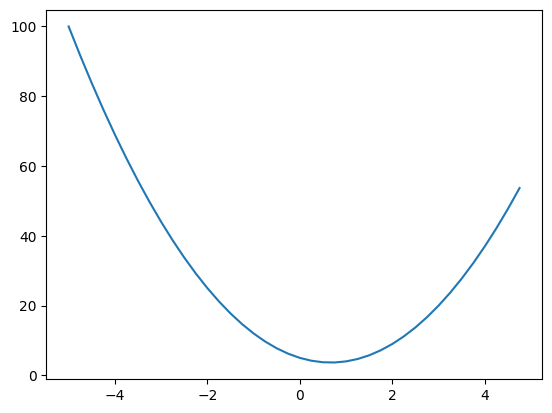

In [ ]:
xs = np.arange(-5,5,.25)
ys = f(xs)
plt.plot(xs,ys)
plt.show()

In [ ]:
h = 0.001
x = 3
(f(x+h) - f(x))/h

14.00300000000243

In [ ]:
#6x - 4 dervative of f(x)
6*3- 4

14

In [ ]:
x = -3
6*(-3) - 4

-22

In [ ]:
h = 0.001
x = -3
(f(x+h) - f(x))/h

-21.996999999998934

In [ ]:
#complex

a = 2.0
b = -3.0
c = 10

d=a*b + c
print(d)

4.0


In [ ]:
h = 0.001
#complex

a = 2.0
b = -3.0
c = 10

# Devrivative wrt a
d1 =a*b + c
a +=  h
d2 =a*b + c
print('d1', d1)
print('d2', d2)
print('Slope', (d2-d1)/h)


d1 4.0
d2 3.997
Slope -3.0000000000001137


In [ ]:
class Value:
  """
  Stores a single scalar value and its gradient,
  keeping track of the operation that produced it for backpropagation.
  """
  def __init__(self, data, _children=(), op='', label='', derivative=''):
    self.data = data # The actual numerical value
    self.grad = 0 # Loss derivative with respect to this value; 0 means no impact initially
    self._prev = set(_children) # Internal variables used for the graph construction
    self._op = op # The operation that created this node (e.g., '+', '*')
    self.label = label # A descriptive string for visualization
    self.derivative = derivative # Textual description of the derivative for visualization

  def __repr__(self):
    # Return a string representation for debugging
    return f"Value(data={self.data})"

  def __add__(self, other):
    # Define addition and store children (self and other) to build the graph
    return Value(self.data + other.data, (self, other), '+')

  def __mul__(self, other):
    # Define multiplication and store children for the computation graph
    return Value(self.data * other.data, (self, other), '*')

  def tanh(self):
    # Tanh activation function used in neural networks
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self,), 'tanh')
    return out

In [ ]:
a = Value(2.0) # a.data = 2
b = Value(3.0) # b.data = 3
a + b # result.data = 5 --> __repr__(result) ==> Value(data=5)


Value(data=5.0)

In [ ]:
a = Value(2.0)  # a.data = 2
b = Value(-3.0)  # b.data = 3
c = Value(10)   # c.data = 10
d = a + b*c # result.data = 32 --> __repr__(result) ==> Value(data=32)
d

Value(data=-28.0)

In [ ]:
d._op, d._prev

('+', {Value(data=-30.0), Value(data=2.0)})

In [ ]:
# Visualisatio
#!pip install graphviz
from graphviz import Digraph

In [ ]:
# Helper functions to visualize the computation graph using Graphviz
def trace(root):
    # Builds a set of all nodes and edges in the graph starting from root
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    Creates a visual representation of the graph.
    data: the actual value
    grad: the gradient (derivative of the output with respect to this node)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir})

    for n in nodes:
        # Display the label, derivative formula, data, and gradient in each node
        label_parts = [n.label]
        if n.derivative: # Only add derivative if it's not empty
            label_parts.append(n.derivative)
        label_parts.append(f"data {n.data:.4f}")
        label_parts.append(f"grad {n.grad:.4f}")
        dot.node(name=str(id(n)), label = "{%s}" % " | ".join(label_parts), shape='record')
        if n._op:
            # If this node is the result of an operation, create an op node
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))

    for n1, n2 in edges:
        # Connect nodes to the operations that consume them
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [ ]:
a = Value(2.0, label= 'a') # a.data = 2
b = Value(-3.0) ; b.label= 'b' # b.data = 3
c = Value(10); c.label= 'c'
e = a*b; e.label= 'e'
d = e + c ; d.label= 'd'
f = Value(-2.0); f.label= 'f'
L = d*f; L.label= 'L'
L

Value(data=-8.0)

In [ ]:
# draw_dot(L)

In [ ]:
def lol():
  # This function demonstrates the numerical derivative (slope)
  # by slightly nudging one value and seeing how much the output changes.
  h = 0.001
  h = Value(h)

  # 1. Baseline Forward Pass
  a = Value(2.0, label='a')
  b = Value(-3.0); b.label = 'b'
  c = Value(10); c.label = 'c'
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0); f.label = 'f'
  L1 = d*f; L1.label = 'L1'

  # 2. Forward Pass with a 'nudge' (h) added to a component
  a = Value(2.0, label='a')
  b = Value(-3.0); b.label = 'b'
  c = Value(10); c.label = 'c'
  e = a*b; e.label = 'e'
  e = e + h # Nudging the intermediate value 'e' by h
  d = e + c; d.label = 'd'
  f = Value(-2.0); f.label = 'f'
  L2 = d*f;

  # The slope is the change in output divided by the nudge amount
  return (L2.data - L1.data) / h.data

In [ ]:
lol()

-2.000000000000668

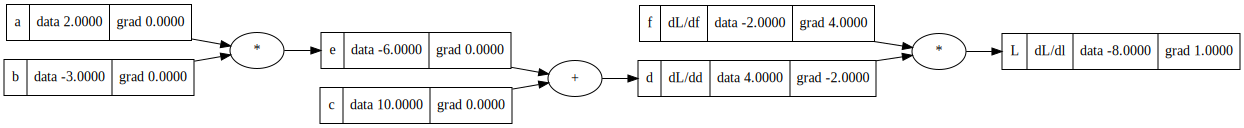

In [ ]:
L.grad = 1
L.derivative= 'dL/dl'
d.grad = -2
d.derivative= 'dL/dd'
f.grad = 4
f.derivative= 'dL/df'
draw_dot(L)

In [ ]:
# we need to find now influance of C on L so dl/dc
# dl/dc = (dd / dc ) * ( dl / dd )

# dd / dc
# d= c + e

# dd/dc = f(x+h) - f(x) / h
# f(x) = c + e
# f(x+h) = c + h + e

# dd/dc= ( c + h + e) -  (c + e) / h
# dd/dc = h / h
# dd/dc = 1

# dl/dc = 1 * (dl / dd)
# dl / dc = 1 * -2.0
# dl / dc = .2.0

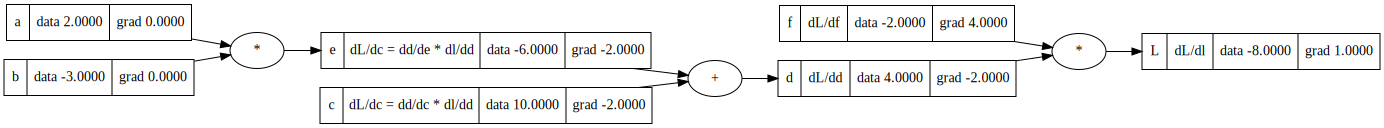

In [ ]:
c.grad = -2
c.derivative = 'dL/dc = dd/dc * dl/dd'
e.grad = -2
e.derivative = 'dL/dc =  dd/de * dl/dd'
draw_dot(L)

In [ ]:
# we need to find now influance of b on L so db/dc
# dl/db = (de / db ) * ( dL / de )

# de / db
# e = a * b

# de / db = f(x+h) - f(x) / h
# f(x) = a * b
# f(x+h) = a * (b + h)

# de/db= ( ab + bh -  (ab) / h
# de/db = bh / h
# de/db = b

# dl/db = (de / db ) * ( dL / de )
# dl/db = -3.0 * (dL / de)
# dl/db = -3.0 * -2.0
# dl/db = 6.0

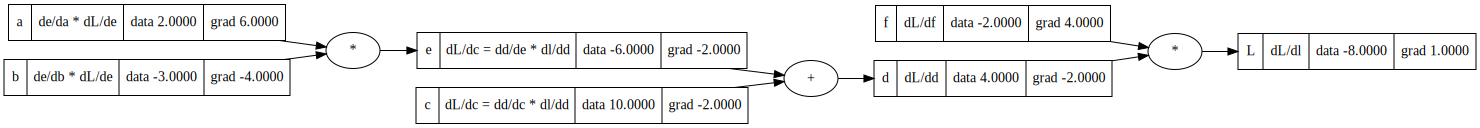

In [ ]:
b.grad = 2.0 * -2.0
b.derivative = 'de/db  * dL/de'
a.grad = -3.0 * -2.0
a.derivative = 'de/da  * dL/de'
draw_dot(L)


In [ ]:
# now lets update the data with learning rate and its gradient
L

Value(data=-8.0)

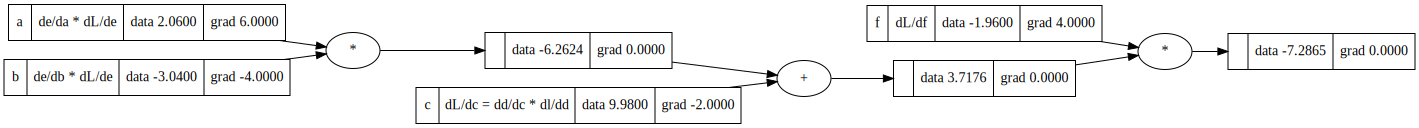

In [ ]:
# Optimization Step: Update parameters using Gradient Descent
h = .01 # Learning rate

# Adjust each variable in the direction that reduces the loss
a.data += h * a.grad
b.data += h * b.grad
c.data += h * c.grad
f.data += h * f.grad

# Perform a manual forward pass with the updated values
e = a * b # Re-calculate e
d = e + c # Re-calculate d
L = d * f # Re-calculate the final output L

# Visualize the updated computation graph
draw_dot(L)

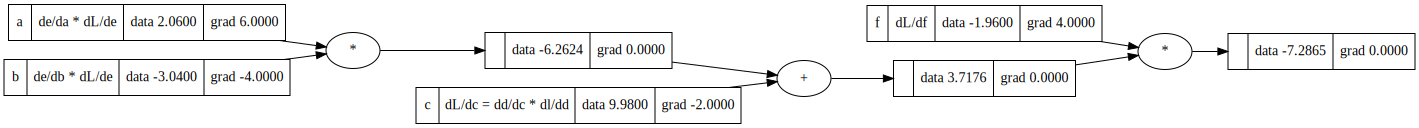

In [ ]:
draw_dot(L)

In [ ]:
# create a nueron with whatever we have built above

![](https://cs231n.github.io/assets/nn1/neuron_model.jpeg)

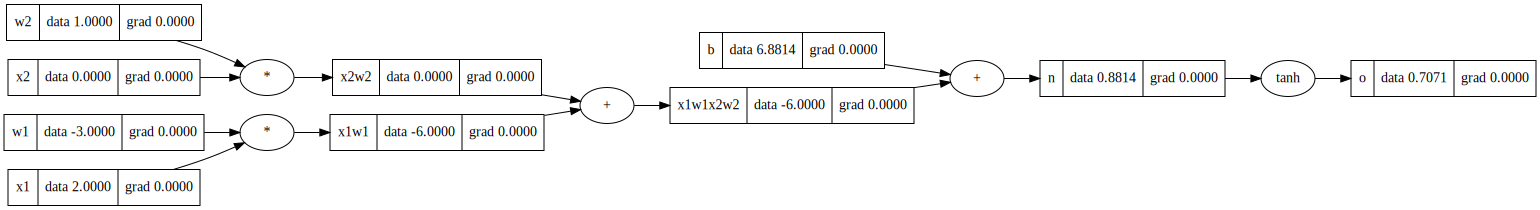

In [ ]:
# --- Step-by-step construction of a single Neuron ---

# 1. Define Inputs: These are the features provided to the neuron
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# 2. Define Weights: These values determine the importance of each input
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# 3. Define Bias: A constant added to the sum to shift the activation
b = Value(6.8813735870195432, label='b')

# 4. Multiply inputs by weights (Linear step)
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'

# 5. Sum the weighted inputs
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'

# 6. Add the bias to get the total logit (pre-activation)
n = x1w1x2w2 + b; n.label = 'n'

# 7. Apply Tanh activation to squash the output between -1 and 1
o = n.tanh(); o.label = 'o'

# 8. Render the initial graph (before backprop)
draw_dot(o)

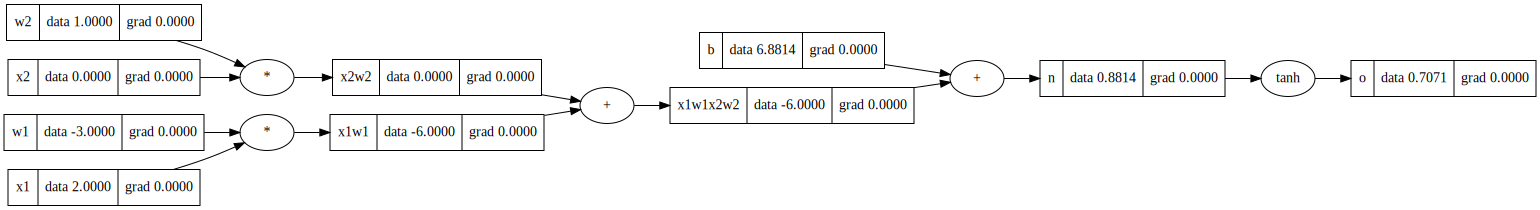

In [ ]:
draw_dot(o)

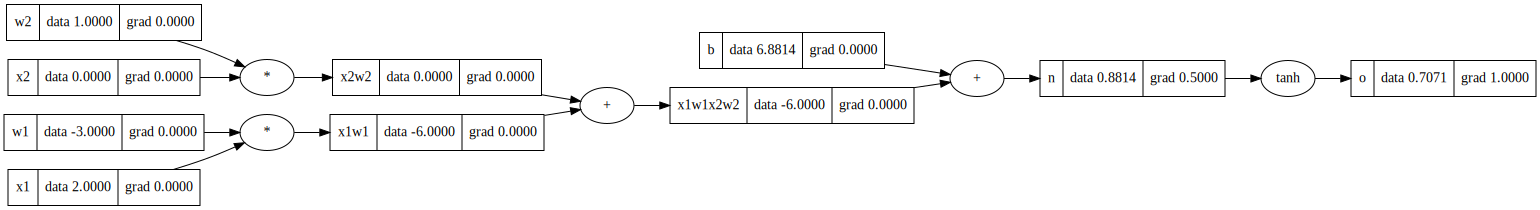

In [ ]:
o.grad=1
# o = tanh(n)
# do/dn = d tanh(n) / dn
# do/dn = 1 - tanh(n)**2
# do/dn = 1 - o **2 ==> o = tanh(n)
#o =  o.data

n.grad = 1 - (o.data)**2
draw_dot(o)

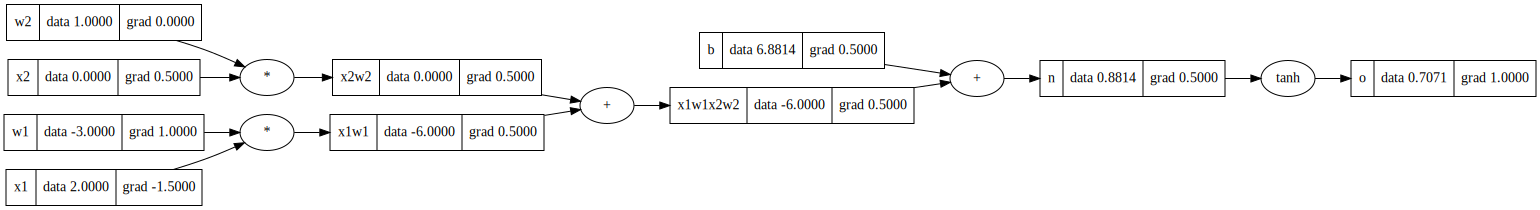

In [ ]:
# --- Manual Backpropagation: Calculating gradients using the Chain Rule ---

# The gradient of the output with respect to itself is always 1
o.grad = 1.0

# Derivative of tanh: do/dn = 1 - tanh(n)**2 = 1 - o**2
n.grad = 1 - o.data**2

# Addition gates (+) simply distribute the gradient to their children
b.grad = n.grad
x1w1x2w2.grad = n.grad

# Again, the addition gate distributes the gradient equally
x1w1.grad = x1w1x2w2.grad
x2w2.grad = x1w1x2w2.grad

# Multiplication gate (*): derivative is (value of the other operand) * (local gradient)
x1.grad = w1.data * x1w1.grad # dL/dx1 = w1 * dL/dx1w1
w1.grad = x1.data * x1w1.grad # dL/dw1 = x1 * dL/dx1w1

x2.grad = w2.data * x2w2.grad # dL/dx2 = w2 * dL/dx2w2
w2.grad = x2.data * x2w2.grad # dL/dw2 = x2 * dL/dx2w2

# Final Visualization showing the flow of gradients
draw_dot(o)

### Automating the Gradient calculation

In [ ]:
class Value:
  """
  Stores a single scalar value and its gradient,
  keeping track of the operation that produced it for backpropagation.
  """
  def __init__(self, data, _children=(), op='', label='', derivative=''):
    self.data = data # The actual numerical value
    self.grad = 0 # Loss derivative with respect to this value; 0 means no impact initially
    self._backward = lambda: None
    self._prev = set(_children) # Internal variables used for the graph construction
    self._op = op # The operation that created this node (e.g., '+', '*')
    self.label = label # A descriptive string for visualization
    self.derivative = derivative # Textual description of the derivative for visualization

  def __repr__(self):
    # Return a string representation for debugging
    out = f"Value(data={self.data})"
    return out

  def __add__(self, other):
    # Define addition and store children (self and other) to build the graph
    out = Value(self.data + other.data, (self, other), '+')
    def _backward():
      self.grad = 1 * out.grad
      other.grad = 1 * out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    # Define multiplication and store children for the computation graph
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad = other.data * out.grad
      other.grad = self.data * out.grad
    out._backward = _backward

    return out

  def tanh(self):
    # Tanh activation function used in neural networks
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self,), 'tanh')

    def _backward():
      self.grad = (1 - t**2) * out.grad
    out._backward = _backward
    return out

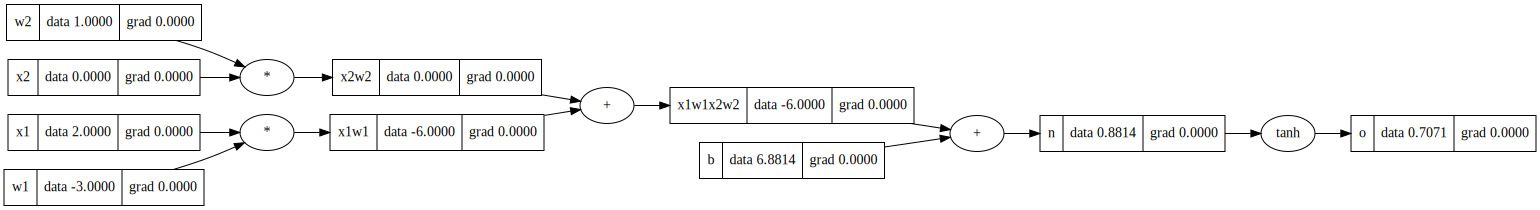

In [ ]:
# --- Step-by-step construction of a single Neuron ---

# 1. Define Inputs: These are the features provided to the neuron
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# 2. Define Weights: These values determine the importance of each input
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# 3. Define Bias: A constant added to the sum to shift the activation
b = Value(6.8813735870195432, label='b')

# 4. Multiply inputs by weights (Linear step)
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'

# 5. Sum the weighted inputs
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'

# 6. Add the bias to get the total logit (pre-activation)
n = x1w1x2w2 + b; n.label = 'n'

# 7. Apply Tanh activation to squash the output between -1 and 1
o = n.tanh(); o.label = 'o'

# 8. Render the initial graph (before backprop)
draw_dot(o)

In [ ]:
# set o.grad to 1 for start
o.grad = 1

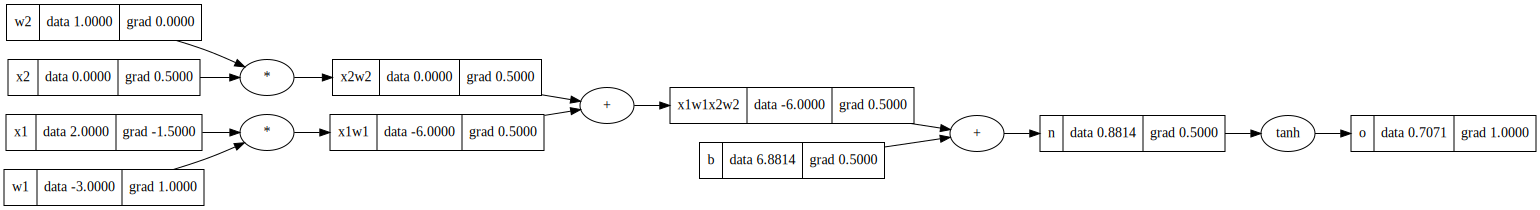

In [ ]:
# do backward for o now
o._backward()
n._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()
draw_dot(o)

In [ ]:
# Create topo logical graph so we travers from left to right while making sure all the right side nodes of any left node are first already traverse - because right node gives the gradient to the left node for its calculation.
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)

o.grad = 1
for node in reversed(topo):
  node._backward()

topo

[Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

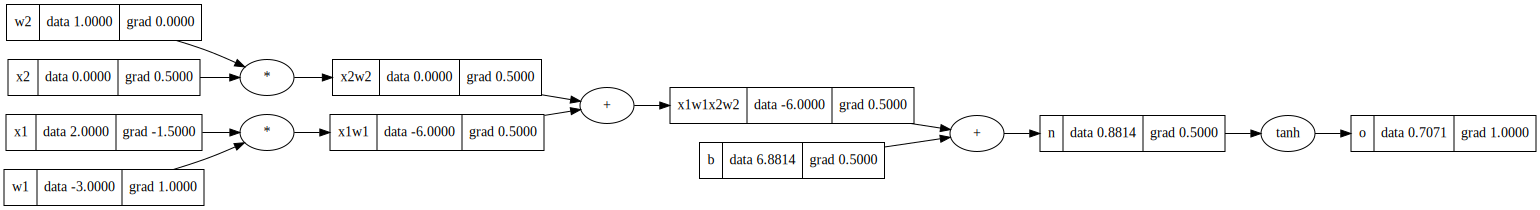

In [ ]:
draw_dot(o)

In [ ]:
class Value:
  """
  Stores a single scalar value and its gradient,
  keeping track of the operation that produced it for backpropagation.
  """
  def __init__(self, data, _children=(), op='', label='', derivative=''):
    self.data = data # The actual numerical value
    self.grad = 0 # Loss derivative with respect to this value; 0 means no impact initially
    self._backward = lambda: None
    self._prev = set(_children) # Internal variables used for the graph construction
    self._op = op # The operation that created this node (e.g., '+', '*')
    self.label = label # A descriptive string for visualization
    self.derivative = derivative # Textual description of the derivative for visualization

  def __repr__(self):
    # Return a string representation for debugging
    out = f"Value(data={self.data})"
    return out

  def __add__(self, other):
    # Define addition and store children (self and other) to build the graph
    out = Value(self.data + other.data, (self, other), '+')
    def _backward():
      self.grad += 1 * out.grad
      other.grad += 1 * out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    # Define multiplication and store children for the computation graph
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  def tanh(self):
    # Tanh activation function used in neural networks
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self,), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()


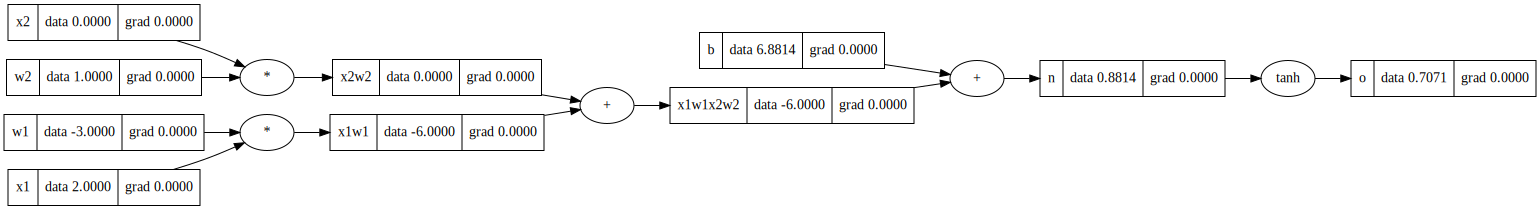

In [ ]:
# --- Step-by-step construction of a single Neuron ---

# 1. Define Inputs: These are the features provided to the neuron
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# 2. Define Weights: These values determine the importance of each input
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# 3. Define Bias: A constant added to the sum to shift the activation
b = Value(6.8813735870195432, label='b')

# 4. Multiply inputs by weights (Linear step)
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'

# 5. Sum the weighted inputs
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'

# 6. Add the bias to get the total logit (pre-activation)
n = x1w1x2w2 + b; n.label = 'n'

# 7. Apply Tanh activation to squash the output between -1 and 1
o = n.tanh(); o.label = 'o'

# 8. Render the initial graph (before backprop)
draw_dot(o)

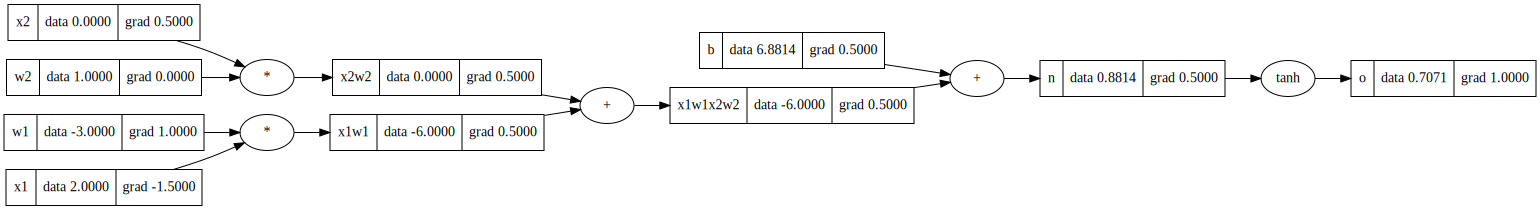

In [ ]:
o.backward()
draw_dot(o)

In [ ]:
class Value:
  """
  Stores a single scalar value and its gradient,
  keeping track of the operation that produced it for backpropagation.
  """
  def __init__(self, data, _children=(), op='', label='', derivative=''):
    self.data = data # The actual numerical value
    self.grad = 0 # Loss derivative with respect to this value; 0 means no impact initially
    self._backward = lambda: None
    self._prev = set(_children) # Internal variables used for the graph construction
    self._op = op # The operation that created this node (e.g., '+', '*')
    self.label = label # A descriptive string for visualization
    self.derivative = derivative # Textual description of the derivative for visualization

  def __repr__(self):
    # Return a string representation for debugging
    out = f"Value(data={self.data})"
    return out

  def __add__(self, other):
    # Define addition and store children (self and other) to build the graph
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')
    def _backward():
      self.grad += 1 * out.grad
      other.grad += 1 * out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    # Define multiplication and store children for the computation graph
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out


  def __rmul__(self, other):
    return self * other

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
      self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward
    return out

  def __truediv__(self, other):
    return self * other**-1


  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self,), 'exp')

    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward
    return out

  def __neg__(self):
    return self * -1

  def __sub__(self, other):
    return self + (-other)

  def tanh(self):
    # Tanh activation function used in neural networks
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self,), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()


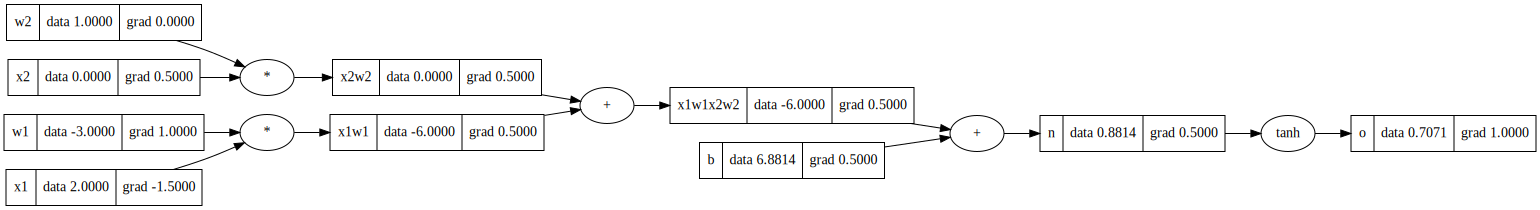

In [ ]:
# --- Step-by-step construction of a single Neuron ---

# 1. Define Inputs: These are the features provided to the neuron
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# 2. Define Weights: These values determine the importance of each input
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# 3. Define Bias: A constant added to the sum to shift the activation
b = Value(6.8813735870195432, label='b')

# 4. Multiply inputs by weights (Linear step)
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'

# 5. Sum the weighted inputs
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'

# 6. Add the bias to get the total logit (pre-activation)
n = x1w1x2w2 + b; n.label = 'n'

# 7. Apply Tanh activation to squash the output between -1 and 1
o = n.tanh(); o.label = 'o'

# Backward pass to calculate gradient
o.backward()

# 8. Render the initial graph (before backprop)
draw_dot(o)

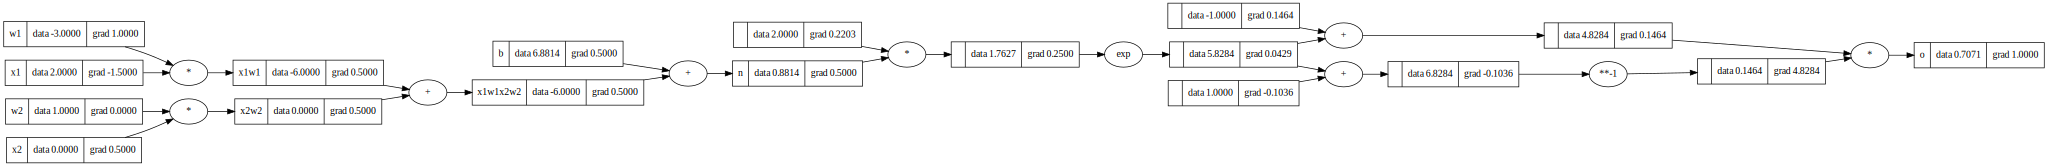

In [ ]:
# rather than tanh we are doing e^2x-1/e^2x+1

# --- Step-by-step construction of a single Neuron ---

# 1. Define Inputs: These are the features provided to the neuron
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# 2. Define Weights: These values determine the importance of each input
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# 3. Define Bias: A constant added to the sum to shift the activation
b = Value(6.8813735870195432, label='b')

# 4. Multiply inputs by weights (Linear step)
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'

# 5. Sum the weighted inputs
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'

# 6. Add the bias to get the total logit (pre-activation)
n = x1w1x2w2 + b; n.label = 'n'

# 7. Apply Tanh activation to squash the output between -1 and 1
# o = n.tanh(); o.label = 'o'
e = (2*n).exp()
o = (e - 1) / (e + 1); o.label = 'o'

# Backward pass to calculate gradient
o.backward()

# 8. Render the initial graph (before backprop)
draw_dot(o)

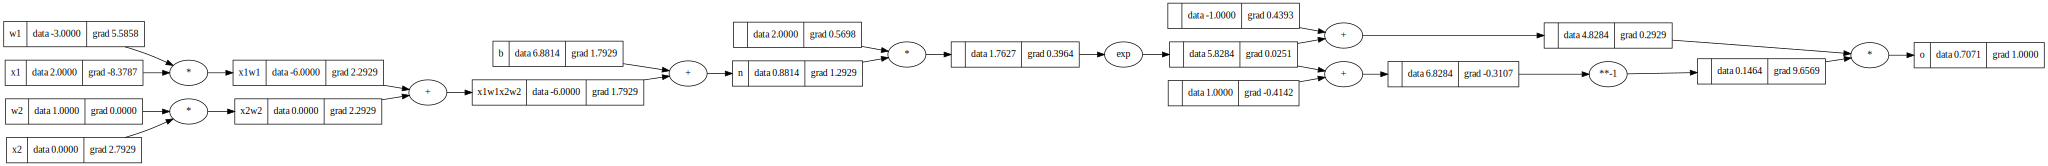

In [ ]:
# Backward pass to calculate gradient
o.backward()

# 8. Render the initial graph (before backprop)
draw_dot(o)

In [ ]:
import random

In [ ]:
class Neuron:
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)),self.b)
    out = act.tanh()
    return out

class Layer:
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs

class MLP:
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
      return x


In [ ]:
n = Neuron(1)
x = [2.0]
n(x)

Value(data=0.4244143429113832)

In [ ]:
n = Neuron(3)
x = [2.0, 3.0, -1.0]

# This works because Neuron(3) created 3 weights to match your 3 inputs
output = n(x)

print(f"Weights: {n.w}")
print(f"Bias: {n.b}")
print(f"Result: {output}")

Weights: [Value(data=0.5772494408024684), Value(data=-0.6340631875136546), Value(data=0.5233624139979445)]
Bias: Value(data=-0.2097004196599439)
Result: Value(data=-0.9016090670530339)
